>>> Using device: cuda

Kích thước train: (809, 13) | Phân bố: Counter({0: 800, 1: 9})
Kích thước val  : (4060, 13) | Phân bố: Counter({0: 4000, 1: 60})
Kích thước test : (6090, 13) | Phân bố: Counter({0: 6000, 1: 90})

Các cột trong X_train:
['Source', 'Length', 'stNum', 'sqNum', 'goID', 'heartbeat', 'dif_stNum', 'dif_sqNum', 'Circuit breaker Open/Close Status', 'I-high VT', 'I-high VT- Tran', 'I-low VT- Tran', 'I-amongst-feeders']

X_train_full shape: (809, 90)
X_val_full shape  : (4060, 90)
X_test_full shape : (6090, 90)
num_features: 90 | num_classes: 2
Client 1: 270 mẫu | phân bố: Counter({np.int64(0): 267, np.int64(1): 3})
Client 2: 270 mẫu | phân bố: Counter({np.int64(0): 267, np.int64(1): 3})
Client 3: 269 mẫu | phân bố: Counter({np.int64(0): 266, np.int64(1): 3})

>>> Model selection by Binary F1 on VALIDATION (FL-style)

################################################################################
### CONFIG 1/1: {'n_rounds': 200, 'local_epochs': 50, 'batch_size': 64, 'lr'

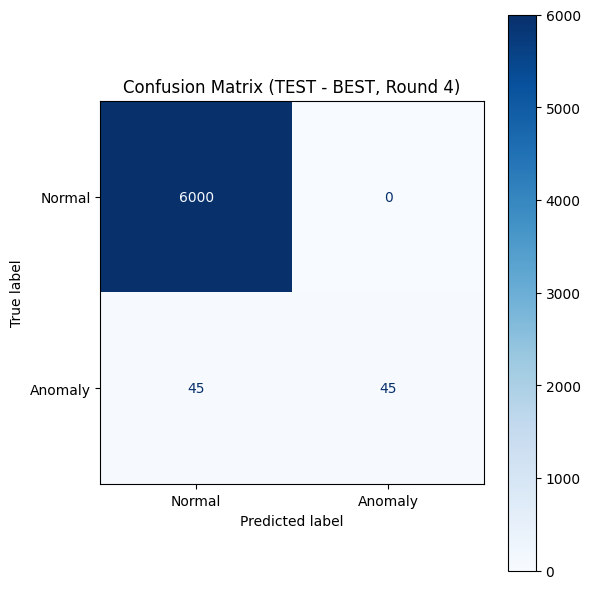

In [1]:
# ============================================================
# FEDERATED LEARNING 3-CLIENT CHO DATA GOOSE (PYTORCH)
# - Đọc: label_pool.csv / val_labeled_40.csv / test_labeled_60.csv
# - Chia TRAIN thành 3 client (stratified)
# - Preprocess: Ordinal + OneHot + StandardScaler (global)
# - Mỗi client:
#     + Balance bằng SMOTE + RandomUnderSampler
#     + Train local model (PyTorch MLP)
# - Server:
#     + FedAvg tham số từ 3 client -> global model
# - TUNING theo kiểu bài trước:
#     + Có search_space nhiều config
#     + Mỗi config chạy nhiều federated rounds
#     + Chọn BEST MODEL theo F1-score BINARY trên VALIDATION
# - In ra:
#     + F1-binary, AUROC, MCC (VAL + TEST) cho best model
#     + Confusion Matrix (TEST) cho best model
# ============================================================

import math
import random
from copy import deepcopy
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    matthews_corrcoef,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --------------------------
# 0) Matplotlib config
# --------------------------
mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.formatter.use_locale"] = False
mpl.rcParams["axes.formatter.use_mathtext"] = False

# --------------------------
# 1) Device + SEED
# --------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(">>> Using device:", device)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# 2) Load CSVs
# ---------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("test_labeled_60.csv")

FEATURES = [c for c in train_df.columns if c != "Label"]
X_train_raw, y_train = train_df[FEATURES].copy(), train_df["Label"].copy()
X_val_raw,   y_val   = val_df[FEATURES].copy(),   val_df["Label"].copy()
X_test_raw,  y_test  = test_df[FEATURES].copy(),  test_df["Label"].copy()

print("\nKích thước train:", X_train_raw.shape, "| Phân bố:", Counter(y_train))
print("Kích thước val  :", X_val_raw.shape,   "| Phân bố:", Counter(y_val))
print("Kích thước test :", X_test_raw.shape,  "| Phân bố:", Counter(y_test))

# Map label string -> 0/1 nếu cần
if y_train.dtype == object:
    label_mapping = {lab: i for i, lab in enumerate(sorted(y_train.unique()))}
    print("Mapping Label:", label_mapping)
    y_train = y_train.map(label_mapping)
    y_val   = y_val.map(label_mapping)
    y_test  = y_test.map(label_mapping)

y_train_np = y_train.to_numpy().astype(np.int64)
y_val_np   = y_val.to_numpy().astype(np.int64)
y_test_np  = y_test.to_numpy().astype(np.int64)

# print("\nPhân bố train sau map:", Counter(y_train_np))
# print("Phân bố val sau map  :", Counter(y_val_np))
# print("Phân bố test sau map :", Counter(y_test_np))

# --------------------------
# 3) ColumnTransformer: impute + encode + StandardScaler
# --------------------------
print("\nCác cột trong X_train:")
print(list(X_train_raw.columns))

num_cols = [
    c for c in [
        "Length", "heartbeat", "I-high VT",
        "I-high VT- Tran", "I-low VT- Tran",
        "I-amongst-feeders", "sqNum"
    ]
    if c in X_train_raw.columns
]

ord_cols = []
if "Circuit breaker Open/Close Status" in X_train_raw.columns:
    ord_cols = ["Circuit breaker Open/Close Status"]
    cb_levels = [np.sort(
        X_train_raw["Circuit breaker Open/Close Status"].dropna().unique()
    ).tolist()]
else:
    cb_levels = None

nom_cols = [
    c for c in ["stNum", "Source", "dif_stNum", "dif_sqNum", "goID"]
    if c in X_train_raw.columns
]

# print("Numeric columns:", num_cols)
# print("Ordinal columns:", ord_cols)
# print("Nominal columns:", nom_cols)

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

if len(ord_cols) > 0:
    ord_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=cb_levels,
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])
else:
    ord_transformer = None

if len(nom_cols) > 0:
    nom_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
else:
    nom_transformer = None

transformers = []
if len(num_cols) > 0:
    transformers.append(("num_feature", num_transformer, num_cols))
if ord_transformer is not None and len(ord_cols) > 0:
    transformers.append(("ord_feature", ord_transformer, ord_cols))
if nom_transformer is not None and len(nom_cols) > 0:
    transformers.append(("nom_feature", nom_transformer, nom_cols))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

reg = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

reg.fit(X_train_raw)
X_train_proc = reg.transform(X_train_raw)
X_val_proc   = reg.transform(X_val_raw)
X_test_proc  = reg.transform(X_test_raw)

X_train_full = X_train_proc.astype(np.float32)
X_val_full   = X_val_proc.astype(np.float32)
X_test_full  = X_test_proc.astype(np.float32)

num_features = X_train_full.shape[1]
num_classes  = len(np.unique(y_train_np))

print("\nX_train_full shape:", X_train_full.shape)
print("X_val_full shape  :", X_val_full.shape)
print("X_test_full shape :", X_test_full.shape)
print("num_features:", num_features, "| num_classes:", num_classes)

# --------------------------
# 4) Chia TRAIN thành 3 client (stratified)
# --------------------------
n_clients = 3
skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=SEED)

client_indices = []
for _, idx in skf.split(X_train_full, y_train_np):
    client_indices.append(idx)

for i, idx in enumerate(client_indices, start=1):
    print(f"Client {i}: {len(idx)} mẫu | phân bố:", Counter(y_train_np[idx]))

# --------------------------
# 5) Định nghĩa model PyTorch
# --------------------------
class MLPClient(nn.Module):
    def __init__(self, in_dim, num_classes, hidden_dims=(32, 64)):
        super().__init__()
        self.hidden_dims = tuple(hidden_dims)
        h1, h2 = self.hidden_dims

        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def get_global_model(hidden_dims=(32, 64)):
    return MLPClient(num_features, num_classes, hidden_dims=hidden_dims).to(device)

# --------------------------
# 6) Hàm FedAvg cho state_dict
# --------------------------
def fedavg_state_dicts(state_dict_list):
    avg_state = {}
    n = len(state_dict_list)
    with torch.no_grad():
        for key in state_dict_list[0].keys():
            avg_state[key] = sum(sd[key] for sd in state_dict_list) / n
    return avg_state

# --------------------------
# 7) Hàm train local 1 client
# --------------------------
def local_train_round(global_model, X_client, y_client,
                      epochs=50, batch_size=64, lr=1e-3, weight_decay=1e-5):
    print(f"[LocalTrain] Trước balancing:", Counter(y_client))

    unique, counts = np.unique(y_client, return_counts=True)
    count_dict = dict(zip(unique, counts))

    if len(unique) == 2 and min(counts) >= 2:
        minority = unique[np.argmin(counts)]
        n_min = count_dict[minority]
        n_min_new = int(n_min * 1.3)  # +30%

        sampling_strategy = {minority: max(n_min_new, n_min + 1)}
        k_neighbors = min(5, n_min - 1) if n_min > 1 else 1

        try:
            smote = SMOTE(
                sampling_strategy=sampling_strategy,
                random_state=SEED,
                k_neighbors=k_neighbors
            )
            X_sm, y_sm = smote.fit_resample(X_client, y_client)

            rus = RandomUnderSampler(random_state=SEED)
            X_bal, y_bal = rus.fit_resample(X_sm, y_sm)

            print(f"[LocalTrain] Sau SMOTE+RUS:", Counter(y_bal))
        except Exception as e:
            print("[LocalTrain] SMOTE/RUS lỗi, dùng data gốc:", e)
            X_bal, y_bal = X_client, y_client
    else:
        print("[LocalTrain] Không áp dụng SMOTE/RUS (thiếu mẫu minority).")
        X_bal, y_bal = X_client, y_client

    X_t = torch.from_numpy(X_bal).float()
    y_t = torch.from_numpy(y_bal).long()

    ds = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    model = MLPClient(
        num_features,
        num_classes,
        hidden_dims=global_model.hidden_dims
    ).to(device)
    model.load_state_dict(global_model.state_dict())

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    return model.state_dict()

# --------------------------
# 8) EVALUATE: F1-binary, AUROC, MCC
# --------------------------
def evaluate_metrics(model, X, y, name="VAL/TEST", verbose=False):
    model.eval()
    X_t = torch.from_numpy(X).float().to(device)
    y_true = y.astype(np.int64)

    with torch.no_grad():
        logits = model(X_t).cpu()

    y_pred = torch.argmax(logits, dim=1).numpy()

    f1_bin = f1_score(
        y_true, y_pred,
        average="binary",
        pos_label=1,
        zero_division=0
    )

    mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.0

    if num_classes == 2:
        try:
            scores = logits[:, 1].numpy()
            auroc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float("nan")
        except Exception:
            auroc = float("nan")
    else:
        auroc = float("nan")

    if verbose:
        print(f"\n=== {name} (verbose) ===")
        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))
        print("Classification Report:")
        print(classification_report(y_true, y_pred, digits=3))

    return f1_bin, auroc, mcc, y_pred

# --------------------------
# 9) Search space (tuning theo kiểu bài trước)
# --------------------------
search_space = [
    # {
    #     "n_rounds": 200,
    #     "local_epochs": 50,
    #     "batch_size": 64,
    #     "lr": 1e-3,
    #     "weight_decay": 1e-3,
    #     "hidden_dims": (32, 64),
    # },
    # {
    #     "n_rounds": 200,
    #     "local_epochs": 30,
    #     "batch_size": 64,
    #     "lr": 1e-3,
    #     "weight_decay": 1e-5,
    #     "hidden_dims": (32, 64),
    # },
    {
        "n_rounds": 200,
        "local_epochs": 50,
        "batch_size": 64,
        "lr": 5e-4,
        "weight_decay": 1e-3,
        "hidden_dims": (32, 64),
    },
    # {
    #     "n_rounds": 150,
    #     "local_epochs": 50,
    #     "batch_size": 64,
    #     "lr": 1e-3,
    #     "weight_decay": 1e-4,
    #     "hidden_dims": (32, 64),
    # },
]

# --------------------------
# 10) Model selection by VAL F1-binary
# --------------------------
best_val_f1_binary = -1.0
best_cfg = None
best_round = None
best_global_state = None
best_val_pack = None

print("\n>>> Model selection by Binary F1 on VALIDATION (FL-style)")

for cfg_idx, cfg in enumerate(search_space, start=1):
    print("\n" + "#" * 80)
    print(f"### CONFIG {cfg_idx}/{len(search_space)}: {cfg}")
    print("#" * 80)

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    global_model = get_global_model(hidden_dims=cfg["hidden_dims"])

    current_best_val_f1 = -1.0
    current_best_round = None
    current_best_state = None
    current_best_pack = None

    for rd in range(1, cfg["n_rounds"] + 1):
        print("\n" + "=" * 60)
        print(f">>> CONFIG {cfg_idx} | FEDERATED ROUND {rd}/{cfg['n_rounds']}")
        print("=" * 60)

        client_states = []

        for cid, idx in enumerate(client_indices, start=1):
            print(f"\n--- Client {cid}: TRAIN LOCAL ---")
            X_c = X_train_full[idx]
            y_c = y_train_np[idx]

            state_c = local_train_round(
                global_model,
                X_c, y_c,
                epochs=cfg["local_epochs"],
                batch_size=cfg["batch_size"],
                lr=cfg["lr"],
                weight_decay=cfg["weight_decay"]
            )
            client_states.append(state_c)

        print("\n--- SERVER: FedAvg ---")
        new_global_state = fedavg_state_dicts(client_states)
        global_model.load_state_dict(new_global_state)

        val_f1_bin, val_auroc, val_mcc, _ = evaluate_metrics(
            global_model,
            X_val_full,
            y_val_np,
            name=f"VAL (Config {cfg_idx}, Round {rd})",
            verbose=False
        )

        print(
            f"[VAL Config {cfg_idx} | Round {rd}] "
            f"F1_binary={val_f1_bin:.4f} | "
            f"AUROC={(val_auroc * 100 if val_auroc == val_auroc else float('nan')):.3f}% | "
            f"MCC={val_mcc:.4f}"
        )

        if val_f1_bin > current_best_val_f1:
            current_best_val_f1 = val_f1_bin
            current_best_round = rd
            current_best_state = {
                k: v.detach().cpu().clone()
                for k, v in global_model.state_dict().items()
            }
            current_best_pack = (val_f1_bin, val_auroc, val_mcc)

    print(
        f"\n>>> BEST of CONFIG {cfg_idx}: "
        f"VAL F1-binary = {current_best_val_f1:.4f} at Round {current_best_round}"
    )

    if current_best_val_f1 > best_val_f1_binary:
        best_val_f1_binary = current_best_val_f1
        best_cfg = deepcopy(cfg)
        best_round = current_best_round
        best_global_state = current_best_state
        best_val_pack = current_best_pack

# --------------------------
# 11) Load best model & report VAL + TEST
# --------------------------
print("\n" + "#" * 60)
print(f"BEST MODEL chọn theo VAL F1-binary = {best_val_f1_binary:.4f}")
print(f"BEST CONFIG = {best_cfg}")
print(f"BEST ROUND  = {best_round}")
print("#" * 60)

assert best_cfg is not None and best_global_state is not None, "Không tìm được best model."

global_model = get_global_model(hidden_dims=best_cfg["hidden_dims"])
global_model.load_state_dict(best_global_state)

# VAL metrics
val_f1_bin, val_auroc, val_mcc, val_pred = evaluate_metrics(
    global_model, X_val_full, y_val_np, name="VAL (BEST)", verbose=False
)
print("\n=== METRICS (VALIDATION - BEST) ===")
print(f"F1-score (binary, VAL) = {val_f1_bin:.4f}")
print(f"AUROC (VAL)            = {(val_auroc * 100 if val_auroc == val_auroc else float('nan')):.3f}%")
print(f"MCC (VAL)              = {val_mcc:.4f}")

# TEST metrics
test_f1_bin, test_auroc, test_mcc, test_pred = evaluate_metrics(
    global_model, X_test_full, y_test_np, name="TEST (BEST)", verbose=False
)
print("\n=== METRICS (TEST - BEST) ===")
print(f"F1-score (binary, TEST) = {test_f1_bin:.4f}")
print(f"AUROC (TEST)            = {(test_auroc * 100 if test_auroc == test_auroc else float('nan')):.3f}%")
print(f"MCC (TEST)              = {test_mcc:.4f}")

# --------------------------
# 12) Confusion Matrix (TEST)
# --------------------------
cm_test = confusion_matrix(y_test_np, test_pred)
print("\nConfusion Matrix (TEST - BEST):")
print(cm_test)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Normal", "Anomaly"]
)
disp.plot(cmap="Blues", colorbar=True, ax=ax)
plt.title(f"Confusion Matrix (TEST - BEST, Round {best_round})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [2]:
# # ============================================================
# # FEDERATED LEARNING 3-CLIENT CHO DATA GOOSE (PYTORCH)
# # - Đọc label_pool / val_labeled_40 / test_labeled_60
# # - Chia TRAIN thành 3 client (stratified)
# # - Preprocess: Ordinal + OneHot + StandardScaler (global)
# # - Mỗi client:
# #     + Lấy phần feature của client
# #     + Balance bằng SMOTE + RandomUnderSampler
# #     + Train local model (PyTorch MLP) vài epoch
# # - Server:
# #     + FedAvg tham số từ 3 client -> global model
# # - Sau R rounds:
# #     + CHỌN BEST MODEL THEO F1-score BINARY trên VALIDATION
# #     + In ra F1-binary, AUROC, MCC (VAL + TEST) cho best model
# # ============================================================

# import math
# import random
# from collections import Counter

# import numpy as np
# import pandas as pd

# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import TensorDataset, DataLoader

# import matplotlib as mpl
# import matplotlib.pyplot as plt

# from sklearn.model_selection import StratifiedKFold
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix,
#     roc_auc_score,
#     f1_score,
#     matthews_corrcoef
# )

# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
# from sklearn.metrics import ConfusionMatrixDisplay
# # --------------------------
# # 0) Matplotlib config (GIỮ NGUYÊN)
# # --------------------------
# mpl.rcParams['axes.formatter.useoffset'] = False
# mpl.rcParams['axes.formatter.use_locale'] = False
# mpl.rcParams['axes.formatter.use_mathtext'] = False

# # --------------------------
# # 1) Device + SEED (GIỮ NGUYÊN)
# # --------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(">>> Using device:", device)

# SEED = 42
# torch.manual_seed(SEED)
# np.random.seed(SEED)
# random.seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

# # ---------------------------
# # 2) Load CSVs (GIỮ NGUYÊN)
# # ---------------------------
# train_df = pd.read_csv("label_pool.csv")
# val_df   = pd.read_csv("val_labeled_40.csv")
# test_df  = pd.read_csv("test_labeled_60.csv")

# FEATURES = [c for c in train_df.columns if c != "Label"]
# X_train_raw, y_train = train_df[FEATURES].copy(), train_df["Label"].copy()
# X_val_raw,   y_val   = val_df[FEATURES].copy(),   val_df["Label"].copy()
# X_test_raw,  y_test  = test_df[FEATURES].copy(),  test_df["Label"].copy()

# print("\nKích thước train:", X_train_raw.shape, "| Phân bố:", Counter(y_train))
# print("Kích thước val  :", X_val_raw.shape,   "| Phân bố:", Counter(y_val))
# print("Kích thước test :", X_test_raw.shape,  "| Phân bố:", Counter(y_test))

# # Map label string → 0/1 nếu cần (GIỮ NGUYÊN)
# if y_train.dtype == object:
#     label_mapping = {lab: i for i, lab in enumerate(sorted(y_train.unique()))}
#     print("Mapping Label:", label_mapping)
#     y_train = y_train.map(label_mapping)
#     y_val   = y_val.map(label_mapping)
#     y_test  = y_test.map(label_mapping)

# y_train_np = y_train.to_numpy().astype(np.int64)
# y_val_np   = y_val.to_numpy().astype(np.int64)
# y_test_np  = y_test.to_numpy().astype(np.int64)

# print("\nPhân bố train sau map:", Counter(y_train_np))
# print("Phân bố val sau map  :", Counter(y_val_np))
# print("Phân bố test sau map :", Counter(y_test_np))

# # --------------------------
# # 3) ColumnTransformer: impute + encode + StandardScaler (GIỮ NGUYÊN)
# # --------------------------
# print("\nCác cột trong X_train:")
# print(list(X_train_raw.columns))

# num_cols = [c for c in ['Length', 'heartbeat', 'I-high VT',
#                         'I-high VT- Tran', 'I-low VT- Tran',
#                         'I-amongst-feeders', 'sqNum']
#             if c in X_train_raw.columns]

# ord_cols = []
# if "Circuit breaker Open/Close Status" in X_train_raw.columns:
#     ord_cols = ["Circuit breaker Open/Close Status"]
#     cb_levels = [np.sort(
#         X_train_raw['Circuit breaker Open/Close Status'].dropna().unique()
#     ).tolist()]
# else:
#     cb_levels = None

# nom_cols = [c for c in ['stNum', 'Source', 'dif_stNum', 'dif_sqNum', 'goID']
#             if c in X_train_raw.columns]

# print("Numeric columns:", num_cols)
# print("Ordinal columns:", ord_cols)
# print("Nominal columns:", nom_cols)

# num_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler",  StandardScaler())
# ])

# if len(ord_cols) > 0:
#     ord_transformer = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="most_frequent")),
#         ("encoder", OrdinalEncoder(
#             categories=cb_levels,
#             handle_unknown='use_encoded_value',
#             unknown_value=-1
#         ))
#     ])
# else:
#     ord_transformer = None

# if len(nom_cols) > 0:
#     nom_transformer = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="most_frequent")),
#         ("encoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
#     ])
# else:
#     nom_transformer = None

# transformers = []
# if len(num_cols) > 0:
#     transformers.append(("num_feature", num_transformer, num_cols))
# if ord_transformer is not None and len(ord_cols) > 0:
#     transformers.append(("ord_feature", ord_transformer, ord_cols))
# if nom_transformer is not None and len(nom_cols) > 0:
#     transformers.append(("nom_feature", nom_transformer, nom_cols))

# preprocessor = ColumnTransformer(
#     transformers=transformers,
#     remainder='drop'
# )

# reg = Pipeline(steps=[
#     ("preprocessor", preprocessor)
# ])

# reg.fit(X_train_raw)
# X_train_proc = reg.transform(X_train_raw)
# X_val_proc   = reg.transform(X_val_raw)
# X_test_proc  = reg.transform(X_test_raw)

# X_train_full = X_train_proc.astype(np.float32)
# X_val_full   = X_val_proc.astype(np.float32)
# X_test_full  = X_test_proc.astype(np.float32)

# num_features = X_train_full.shape[1]
# num_classes  = len(np.unique(y_train_np))

# print("\nX_train_full shape:", X_train_full.shape)
# print("X_val_full shape  :", X_val_full.shape)
# print("X_test_full shape :", X_test_full.shape)
# print("num_features:", num_features, "| num_classes:", num_classes)

# # --------------------------
# # 4) Chia TRAIN thành 3 client (stratified) (GIỮ NGUYÊN)
# # --------------------------
# n_clients = 3
# skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=SEED)

# client_indices = []
# for _, idx in skf.split(X_train_full, y_train_np):
#     client_indices.append(idx)

# for i, idx in enumerate(client_indices):
#     print(f"Client {i+1}: {len(idx)} mẫu | phân bố:", Counter(y_train_np[idx]))

# # --------------------------
# # 5) Định nghĩa model PyTorch (GIỮ NGUYÊN)
# # --------------------------
# class MLPClient(nn.Module):
#     def __init__(self, in_dim, num_classes):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(in_dim, 32),
#             nn.ReLU(),
#             nn.Linear(32, 64),
#             nn.ReLU(),
#             nn.Linear(64, num_classes)
#         )

#     def forward(self, x):
#         return self.net(x)

# def get_global_model():
#     model = MLPClient(num_features, num_classes).to(device)
#     return model

# # --------------------------
# # 6) Hàm FedAvg cho state_dict (GIỮ NGUYÊN)
# # --------------------------
# def fedavg_state_dicts(state_dict_list):
#     avg_state = {}
#     n = len(state_dict_list)
#     with torch.no_grad():
#         for key in state_dict_list[0].keys():
#             avg_state[key] = sum(sd[key] for sd in state_dict_list) / n
#     return avg_state

# # --------------------------
# # 7) Hàm train local 1 client (GIỮ NGUYÊN)
# # --------------------------
# def local_train_round(global_model, X_client, y_client,
#                       epochs=50, batch_size=64, lr=1e-3):
#     print(f"[LocalTrain] Trước balancing:", Counter(y_client))
#     unique, counts = np.unique(y_client, return_counts=True)
#     count_dict = dict(zip(unique, counts))

#     if len(unique) == 2 and min(counts) >= 2:
#         minority = unique[np.argmin(counts)]
#         n_min = count_dict[minority]
#         n_min_new = int(n_min * 1.3)  # +30%

#         sampling_strategy = {minority: max(n_min_new, n_min + 1)}
#         k_neighbors = min(5, n_min - 1) if n_min > 1 else 1

#         try:
#             smote = SMOTE(
#                 sampling_strategy=sampling_strategy,
#                 random_state=SEED,
#                 k_neighbors=k_neighbors
#             )
#             X_sm, y_sm = smote.fit_resample(X_client, y_client)
#             rus = RandomUnderSampler(random_state=SEED)
#             X_bal, y_bal = rus.fit_resample(X_sm, y_sm)
#             print(f"[LocalTrain] Sau SMOTE+RUS:", Counter(y_bal))
#         except Exception as e:
#             print("[LocalTrain] SMOTE/RUS lỗi, dùng data gốc:", e)
#             X_bal, y_bal = X_client, y_client
#     else:
#         print("[LocalTrain] Không áp dụng SMOTE/RUS (thiếu mẫu minority).")
#         X_bal, y_bal = X_client, y_client

#     X_t = torch.from_numpy(X_bal).float()
#     y_t = torch.from_numpy(y_bal).long()

#     ds = TensorDataset(X_t, y_t)
#     loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

#     model = MLPClient(num_features, num_classes).to(device)
#     model.load_state_dict(global_model.state_dict())

#     criterion = nn.CrossEntropyLoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

#     model.train()
#     for ep in range(epochs):
#         for xb, yb in loader:
#             xb = xb.to(device)
#             yb = yb.to(device)

#             optimizer.zero_grad()
#             logits = model(xb)
#             loss = criterion(logits, yb)
#             loss.backward()
#             optimizer.step()

#     return model.state_dict()

# # --------------------------
# # 8) EVALUATE: trả về F1-binary, AUROC, MCC (CHỈ THÊM/ĐỔI PHẦN METRICS)
# # --------------------------
# def evaluate_metrics(model, X, y, name="VAL/TEST", verbose=False):
#     model.eval()
#     X_t = torch.from_numpy(X).float().to(device)
#     y_true = y.astype(np.int64)

#     with torch.no_grad():
#         logits = model(X_t).cpu()  # [N, C]

#     y_pred = torch.argmax(logits, dim=1).numpy()

#     # F1-binary (pos_label=1)
#     f1_bin = f1_score(y_true, y_pred, average="binary", pos_label=1, zero_division=0)

#     # MCC
#     mcc = matthews_corrcoef(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.0

#     # AUROC (dùng logit class 1 làm score liên tục)
#     if num_classes == 2:
#         try:
#             scores = logits[:, 1].numpy()
#             auroc = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float("nan")
#         except Exception:
#             auroc = float("nan")
#     else:
#         auroc = float("nan")

#     if verbose:
#         print(f"\n=== {name} (verbose) ===")
#         print("Confusion Matrix:")
#         print(confusion_matrix(y_true, y_pred))
#         print("Classification Report:")
#         print(classification_report(y_true, y_pred, digits=3))

#     return f1_bin, auroc, mcc, y_pred

# # --------------------------
# # 9) Vòng lặp Federated Learning (GIỮ NGUYÊN hyperparams)
# #     -> CHỌN BEST THEO VAL F1-BINARY
# # --------------------------
# global_model = get_global_model()
# n_rounds = 200

# best_val_f1_binary = -1.0
# best_round = None
# best_global_state = None
# best_val_pack = None  # (f1, auroc, mcc)

# for rd in range(1, n_rounds + 1):
#     print("\n" + "="*60)
#     print(f">>> FEDERATED ROUND {rd}/{n_rounds}")
#     print("="*60)

#     client_states = []

#     for cid, idx in enumerate(client_indices, start=1):
#         print(f"\n--- Client {cid}: TRAIN LOCAL ---")
#         X_c = X_train_full[idx]
#         y_c = y_train_np[idx]
#         state_c = local_train_round(
#             global_model,
#             X_c, y_c,
#             epochs=50,       # GIỮ NGUYÊN
#             batch_size=64,  # GIỮ NGUYÊN
#             lr=1e-3         # GIỮ NGUYÊN
#         )
#         client_states.append(state_c)

#     print("\n--- SERVER: FedAvg ---")
#     new_global_state = fedavg_state_dicts(client_states)
#     global_model.load_state_dict(new_global_state)

#     # ===== Evaluate VAL (chỉ để chọn best theo F1-binary) =====
#     val_f1_bin, val_auroc, val_mcc, _ = evaluate_metrics(
#         global_model, X_val_full, y_val_np, name=f"VAL (Round {rd})", verbose=False
#     )
#     print(f"\n[VAL Round {rd}] F1_binary={val_f1_bin:.4f} | AUROC={(val_auroc*100 if val_auroc==val_auroc else float('nan')):.3f}% | MCC={val_mcc:.4f}")

#     # ===== Lưu BEST theo VAL F1-binary =====
#     if val_f1_bin > best_val_f1_binary:
#         best_val_f1_binary = val_f1_bin
#         best_round = rd
#         best_global_state = {k: v.detach().cpu().clone() for k, v in global_model.state_dict().items()}
#         best_val_pack = (val_f1_bin, val_auroc, val_mcc)

# # --------------------------
# # 10) Load best model & in 3 chỉ số cho VAL + TEST
# # --------------------------
# print("\n" + "#"*60)
# print(f"BEST MODEL chọn theo VAL F1-binary = {best_val_f1_binary:.4f} (Round {best_round})")
# print("#"*60)

# if best_global_state is not None:
#     global_model.load_state_dict(best_global_state)

# # VAL metrics (best)
# val_f1_bin, val_auroc, val_mcc, val_pred = evaluate_metrics(
#     global_model, X_val_full, y_val_np, name="VAL (BEST)", verbose=False
# )
# print("\n=== METRICS (VALIDATION - BEST) ===")
# print(f"F1-score (binary, VAL) = {val_f1_bin:.4f}")
# print(f"AUROC (VAL)            = {(val_auroc*100 if val_auroc==val_auroc else float('nan')):.3f}%")
# print(f"MCC (VAL)              = {val_mcc:.4f}")

# # TEST metrics (best)
# test_f1_bin, test_auroc, test_mcc, test_pred = evaluate_metrics(
#     global_model, X_test_full, y_test_np, name="TEST (BEST)", verbose=False
# )
# print("\n=== METRICS (TEST - BEST) ===")
# print(f"F1-score (binary, TEST) = {test_f1_bin:.4f}")
# print(f"AUROC (TEST)            = {(test_auroc*100 if test_auroc==test_auroc else float('nan')):.3f}%")
# print(f"MCC (TEST)              = {test_mcc:.4f}")

# # (Optional) Confusion Matrix để bạn xem (không đổi hyperparameter)
# cm_test = confusion_matrix(y_test_np, test_pred)
# print("\nConfusion Matrix (TEST - BEST):")
# print(cm_test)

# fig, ax = plt.subplots(figsize=(6, 6))
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Normal", "Anomaly"])
# disp.plot(cmap="Blues", colorbar=True, ax=ax)
# plt.title(f"Confusion Matrix (TEST - BEST, Round {best_round})")
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.tight_layout()
# plt.show()
